In [3]:
import pandas as pd

df = pd.read_csv('../data/IMDB Dataset.csv')
df.shape
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape
df['sentiment'].value_counts()
df.isnull().sum()
df.duplicated().sum()

np.int64(418)

In [5]:
df['review_length'] = df['review'].apply(len)
df['review_length'].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

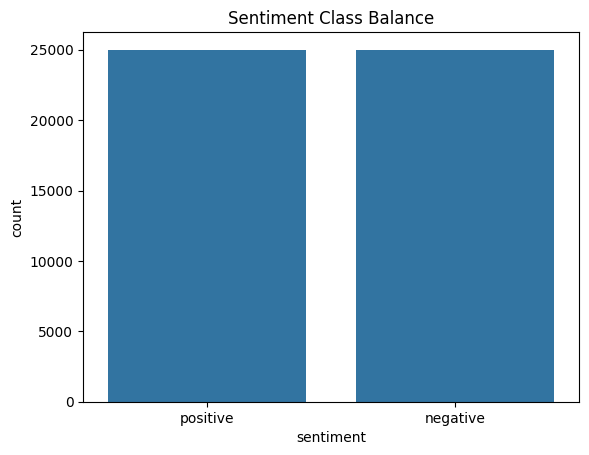

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Class Balance')
plt.savefig('../images/class_balance.png')
plt.show()

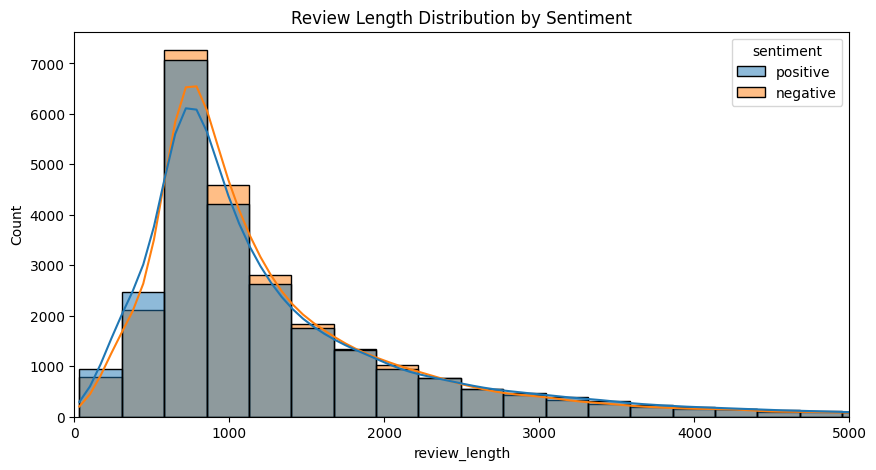

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True)
plt.title('Review Length Distribution by Sentiment')
plt.xlim(0, 5000)
plt.savefig('../images/review_length_dist.png')
plt.show()

In [8]:
import sys
!{sys.executable} -m pip install wordcloud --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


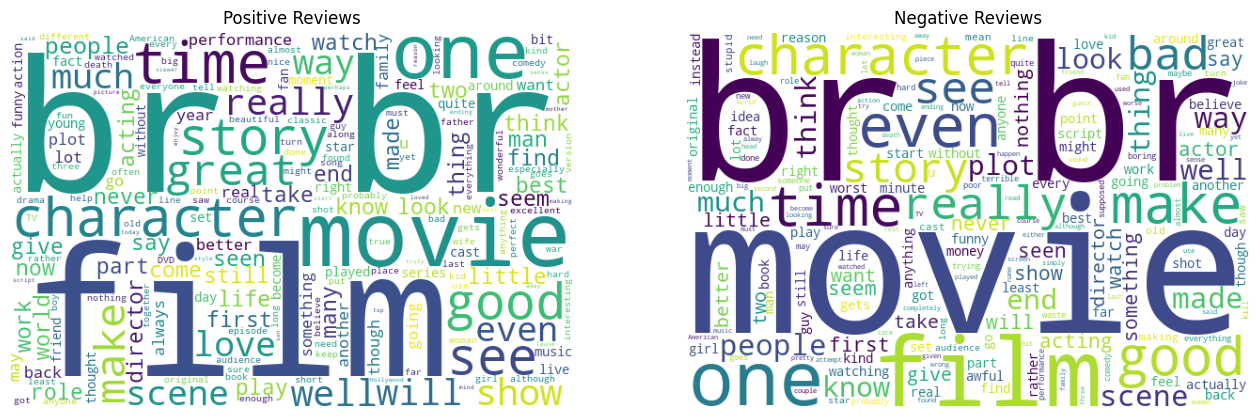

In [9]:
from wordcloud import WordCloud

positive_text = ' '.join(df[df['sentiment']=='positive']['review'].sample(2000))
negative_text = ' '.join(df[df['sentiment']=='negative']['review'].sample(2000))

fig, axes = plt.subplots(1, 2, figsize=(16,6))

wc_pos = WordCloud(width=600, height=400, background_color='white').generate(positive_text)
axes[0].imshow(wc_pos)
axes[0].set_title('Positive Reviews')
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='white').generate(negative_text)
axes[1].imshow(wc_neg)
axes[1].set_title('Negative Reviews')
axes[1].axis('off')

plt.savefig('../images/wordclouds.png')
plt.show()

In [10]:
import sys
!{sys.executable} -m pip install nltk --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\om.ak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\om.ak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\om.ak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          
    text = re.sub(r'[^a-zA-Z\s]', '', text)      
    text = text.lower()                          
    words = text.split()
    words = [w for w in words if w not in stop_words]  
    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [13]:
sample = df['clean_review'].iloc[0].split()[:15]

stemmed = [stemmer.stem(w) for w in sample]
lemmatized = [lemmatizer.lemmatize(w) for w in sample]

print("Original:", sample)
print("Stemmed:", stemmed)
print("Lemmatized:", lemmatized)

Original: ['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz']
Stemmed: ['one', 'review', 'mention', 'watch', 'oz', 'episod', 'youll', 'hook', 'right', 'exactli', 'happen', 'first', 'thing', 'struck', 'oz']
Lemmatized: ['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz']


In [14]:
df['final_review'] = df['clean_review'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(w) for w in x.split()])
)
df[['review', 'final_review']].head()

,review,final_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [15]:
from sklearn.model_selection import train_test_split

X = df['final_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((40000,), (10000,))

In [16]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_bow.shape, X_train_tfidf.shape

((40000, 5000), (40000, 5000))

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
acc_bow = accuracy_score(y_test, lr_bow.predict(X_test_bow))

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
acc_tfidf = accuracy_score(y_test, lr_tfidf.predict(X_test_tfidf))

print(f"Bag of Words accuracy: {acc_bow:.4f}")
print(f"TF-IDF accuracy: {acc_tfidf:.4f}")

Bag of Words accuracy: 0.8702
TF-IDF accuracy: 0.8883


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start
    
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    
    results[name] = {'accuracy': acc, 'train_time': train_time, 'model': model}
    print(f"{name:25s} | Accuracy: {acc:.4f} | Train time: {train_time:.2f}s")

Logistic Regression       | Accuracy: 0.8883 | Train time: 0.90s
Naive Bayes               | Accuracy: 0.8531 | Train time: 0.04s
Linear SVM                | Accuracy: 0.8835 | Train time: 1.01s
Random Forest             | Accuracy: 0.8459 | Train time: 41.65s


              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



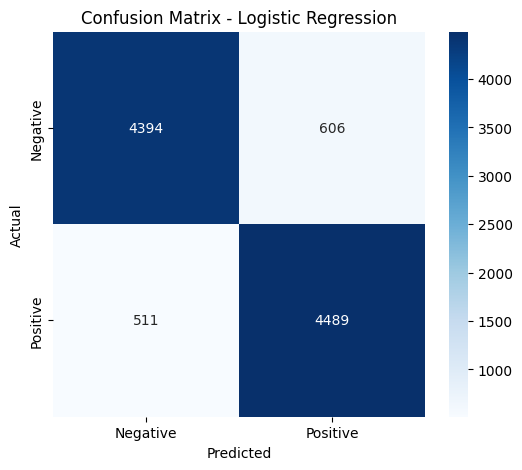

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

best_model = results['Logistic Regression']['model']
preds = best_model.predict(X_test_tfidf)

print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.savefig('../images/confusion_matrix.png')
plt.show()

In [20]:
import joblib

joblib.dump(best_model, '../models/sentiment_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [21]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    lemmatized = ' '.join([lemmatizer.lemmatize(w) for w in cleaned.split()])
    vec = tfidf.transform([lemmatized])
    pred = best_model.predict(vec)[0]
    prob = best_model.predict_proba(vec)[0]
    return {
        'sentiment': 'Positive' if pred == 1 else 'Negative',
        'confidence': f"{max(prob)*100:.2f}%"
    }

# Test on custom reviews
test_reviews = [
    "This movie was absolutely fantastic, great acting and plot!",
    "Waste of time, terrible script and bad direction.",
    "It was okay, nothing special but not bad either."
]

for r in test_reviews:
    result = predict_sentiment(r)
    print(f"Review: {r}")
    print(f"Prediction: {result['sentiment']} ({result['confidence']})\n")


Review: This movie was absolutely fantastic, great acting and plot!
Prediction: Positive (93.67%)

Review: Waste of time, terrible script and bad direction.
Prediction: Negative (100.00%)

Review: It was okay, nothing special but not bad either.
Prediction: Negative (99.79%)



In [22]:
from sklearn.model_selection import GridSearchCV

tfidf_v2 = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)
X_train_tfidf_v2 = tfidf_v2.fit_transform(X_train)
X_test_tfidf_v2 = tfidf_v2.transform(X_test)

param_grid = {'C': [0.1, 1, 5, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_tfidf_v2, y_train)

print("Best C:", grid.best_params_)
best_model_v2 = grid.best_estimator_

acc_v2 = accuracy_score(y_test, best_model_v2.predict(X_test_tfidf_v2))
print(f"New accuracy (bigrams + tuned): {acc_v2:.4f}")
print(f"Old accuracy (baseline): {results['Logistic Regression']['accuracy']:.4f}")

Best C: {'C': 5}
New accuracy (bigrams + tuned): 0.8959
Old accuracy (baseline): 0.8883


In [23]:
import sys
!{sys.executable} -m pip install lime --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


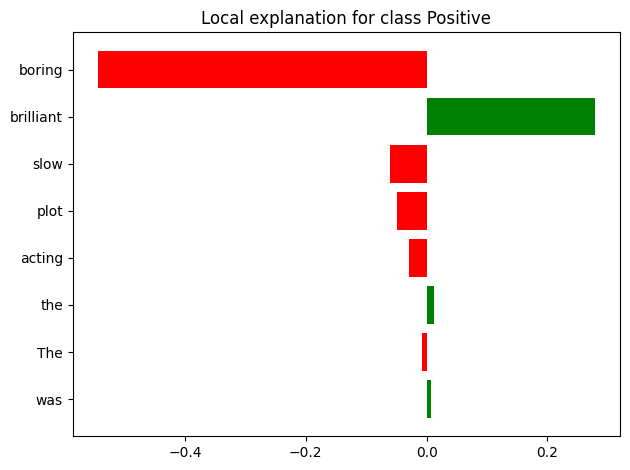

[(np.str_('boring'), -0.5445398495582447), (np.str_('brilliant'), 0.2789418487333318), (np.str_('slow'), -0.06041619456245051), (np.str_('plot'), -0.04881171157164548), (np.str_('acting'), -0.029700301849457284), (np.str_('the'), 0.01245468155665195), (np.str_('The'), -0.006863809127963177), (np.str_('was'), 0.006641003101563819)]


In [24]:
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

def predict_proba_for_lime(texts):
    cleaned = [' '.join([lemmatizer.lemmatize(w) for w in clean_text(t).split()]) for t in texts]
    vecs = tfidf_v2.transform(cleaned)
    return best_model_v2.predict_proba(vecs)

sample_review = "The acting was brilliant but the plot was too slow and boring."

exp = explainer.explain_instance(sample_review, predict_proba_for_lime, num_features=8)

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig('../images/lime_explanation.png')
plt.show()

print(exp.as_list())

In [25]:
joblib.dump(best_model_v2, '../models/sentiment_model.pkl')
joblib.dump(tfidf_v2, '../models/tfidf_vectorizer.pkl')
print("Updated model saved.")

Updated model saved.


In [26]:
# Error analysis: find misclassified reviews
y_pred_v2 = best_model_v2.predict(X_test_tfidf_v2)

errors = pd.DataFrame({
    'review': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred_v2
})

misclassified = errors[errors['actual'] != errors['predicted']]
print(f"Total misclassified: {len(misclassified)} out of {len(errors)} ({len(misclassified)/len(errors)*100:.2f}%)")

# Look at a few examples
misclassified.sample(5, random_state=42)

Total misclassified: 1041 out of 10000 (10.41%)


,review,actual,predicted
1178,went cinema expecting biggish budget release g...,1,0
6020,might contain spoiler beware thousand two mill...,1,0
1654,watched film noticed kari wuhrer cast long the...,0,1
298,remember watching bsg pilot describe night exa...,0,1
6554,simply love movie perfect example wellrounded ...,1,0


In [27]:
for idx, row in misclassified.sample(5, random_state=42).iterrows():
    print(f"Actual: {'Positive' if row['actual']==1 else 'Negative'} | Predicted: {'Positive' if row['predicted']==1 else 'Negative'}")
    print(f"Review: {row['review']}")
    print("-" * 80)

Actual: Positive | Predicted: Negative
Review: went cinema expecting biggish budget release got arthouse movie movie projected digitally onto two third screen real estate sloping edge classic digital projection limited stereo soundtrack wasted cinema experience content film old historical content seen heavily sanitized prevent audience sick live action scene little reused constantly classic documentary style became annoying somewhat amazed people turned watch guess rest knew something didnt suspect producer made film recognize ninetieth anniversary gallipoli question whether bothered seven ten trying respect anzac
--------------------------------------------------------------------------------
Actual: Positive | Predicted: Negative
Review: might contain spoiler beware thousand two million people make difference sometimes get angry apparent apathy small number strangely loud american remember many people u bred raised care anything outside comfort zone god help u done relative ease nati

In [28]:
import os
from datetime import datetime

version = datetime.now().strftime("%Y%m%d")
os.makedirs('../models/versions', exist_ok=True)

joblib.dump(best_model_v2, f'../models/versions/sentiment_model_v{version}.pkl')
joblib.dump(tfidf_v2, f'../models/versions/tfidf_vectorizer_v{version}.pkl')

joblib.dump(best_model_v2, '../models/sentiment_model.pkl')
joblib.dump(tfidf_v2, '../models/tfidf_vectorizer.pkl')

print(f"Model versioned and saved: v{version}")

Model versioned and saved: v20260827


In [29]:
from sklearn.model_selection import train_test_split

X = df['final_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((40000,), (10000,))

In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_bow.shape, X_train_tfidf.shape

((40000, 5000), (40000, 5000))

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
acc_bow = accuracy_score(y_test, lr_bow.predict(X_test_bow))

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
acc_tfidf = accuracy_score(y_test, lr_tfidf.predict(X_test_tfidf))

print(f"Bag of Words accuracy: {acc_bow:.4f}")
print(f"TF-IDF accuracy: {acc_tfidf:.4f}")

Bag of Words accuracy: 0.8702
TF-IDF accuracy: 0.8883


In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM (Linear)': LinearSVC(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    elapsed = time.time() - start
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'Time (s)': elapsed
    }

results_df = pd.DataFrame(results).T
results_df.sort_values('Accuracy', ascending=False)

,Accuracy,Precision,Recall,F1,Time (s)
Logistic Regression,0.8883,0.881060,0.8978,0.889351,1.614042
SVM (Linear),0.8835,0.878578,0.8900,0.884252,1.233298
Naive Bayes,0.8531,0.848844,0.8592,0.853991,0.070787
Random Forest,0.8459,0.853898,0.8346,0.844139,272.619405


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

grid.best_params_, grid.best_score_

c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


({'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}, np.float64(0.884775))

In [34]:
best_lr = grid.best_estimator_
preds = best_lr.predict(X_test_tfidf)

print("Tuned Accuracy:", accuracy_score(y_test, preds))
print("Tuned F1:", f1_score(y_test, preds))

Tuned Accuracy: 0.8883
Tuned F1: 0.8893730811132019


In [35]:
grid.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

In [36]:
feature_names = tfidf.get_feature_names_out()
coefs = best_lr.coef_[0]

top_positive = pd.Series(coefs, index=feature_names).sort_values(ascending=False).head(15)
top_negative = pd.Series(coefs, index=feature_names).sort_values(ascending=True).head(15)

print("Top words pushing toward POSITIVE:")
print(top_positive)
print("\nTop words pushing toward NEGATIVE:")
print(top_negative)

Top words pushing toward POSITIVE:
great        6.990878
excellent    6.931838
perfect      5.439828
amazing      5.025009
best         4.786393
loved        4.581603
wonderful    4.541320
favorite     4.504279
hilarious    4.487306
enjoyed      4.232794
today        4.027490
brilliant    3.987690
fun          3.938132
highly       3.850884
enjoyable    3.813554
dtype: float64

Top words pushing toward NEGATIVE:
worst           -10.318891
waste            -8.105743
awful            -7.685205
bad              -7.387434
boring           -6.383544
poor             -5.727468
terrible         -5.619115
nothing          -5.316379
poorly           -5.132528
horrible         -5.104917
dull             -5.041249
worse            -5.015465
fails            -4.933302
disappointing    -4.605909
unfortunately    -4.438323
dtype: float64


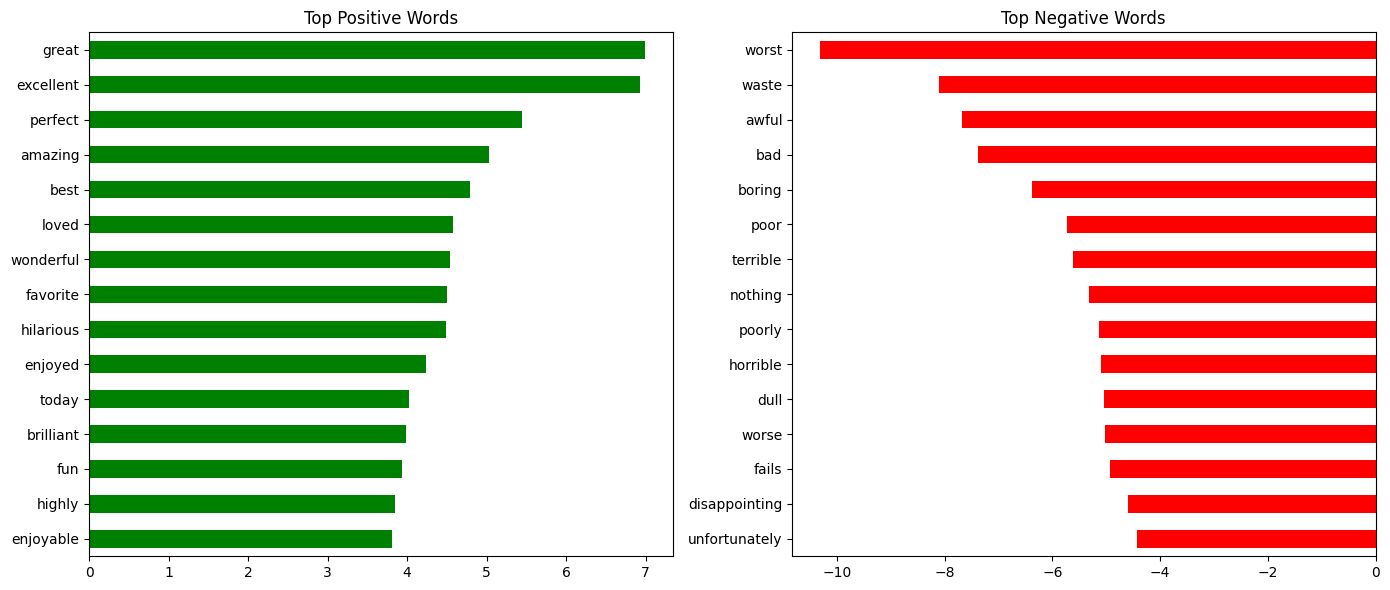

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
top_positive.plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top Positive Words')
axes[0].invert_yaxis()

top_negative.plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top Negative Words')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../images/top_words.png')
plt.show()

In [38]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_lr, '../models/sentiment_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Saved!")

Saved!


In [40]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=20, random_state=42)
mlp.fit(X_train_tfidf, y_train)

preds = mlp.predict(X_test_tfidf)
print("Neural Network Accuracy:", accuracy_score(y_test, preds))
print("Neural Network F1:", f1_score(y_test, preds))

Neural Network Accuracy: 0.8718
Neural Network F1: 0.8728174603174603


c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [41]:
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression (tuned)', 'SVM', 'Naive Bayes', 'Random Forest', 'Neural Network (MLP)'],
    'Accuracy': [0.8883, 0.8835, 0.8531, 0.8459, 0.8718],
    'F1': [0.8894, 0.8843, 0.8540, 0.8441, 0.8728]
})
results_summary.sort_values('Accuracy', ascending=False)

,Model,Accuracy,F1
0,Logistic Regression (tuned),0.8883,0.8894
1,SVM,0.8835,0.8843
4,Neural Network (MLP),0.8718,0.8728
2,Naive Bayes,0.8531,0.8540
3,Random Forest,0.8459,0.8441
